In [1]:
import numpy as np
import pandas as pd
import warnings

# --- 1. Import Models ---
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# --- 2. Import GPR Kernels ---
# Import the kernel objects you want to test
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic

# --- 3. Import the Workflow ---
# This assumes 'armote.py' is in the same directory as this script
try:
    from armote_cv import run_workflow
except ImportError:
    print("="*80)
    print("ERROR: 'armote.py' not found.")
    print("Please make sure 'armote.py' is in the same directory as this run script.")
    print("="*80)
    exit()

In [2]:
# Suppress common warnings from scikit-learn/Keras for a cleaner log
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
df = pd.read_excel('Grain_Size_Summary_v3.xlsx')
df.head()

,Alloy Name,Al,Co,Cr,Cu,Fe,Mn,Ni,V,"Hardness, HV","SD, HV",YS (MPa),"SD, YS",Cold Work (%Reduction),Recrystallization Temp(℃),Holding time (h),Grain Size(µm),"SD, Grain Size(µm)"
0,BBA01,4,8.0,4,4,16.0,12,48.0,4,140.2,3.8,284.2,34.3,60,950,0.5,23.00,13.00
1,BBA02,4,16.0,0,4,12.0,8,52.0,4,151.5,5.7,301.0,6.6,60,950,0.5,31.94,18.45
2,BBA03,4,12.0,8,4,16.0,8,48.0,0,128.9,3.1,217.6,4.8,60,950,0.5,39.92,24.35
3,BBA05,4,12.0,8,0,8.0,8,56.0,4,157.8,3.7,313.1,5.7,60,950,0.5,33.83,22.49
4,BBA06,4,0.0,8,4,24.0,12,44.0,4,118.6,2.1,230.5,3.6,60,950,0.5,46.40,29.77


In [4]:
# Composition columns
composition_cols = ['Al', 'Co', 'Cr', 'Cu', 'Fe', 'Mn', 'Ni', 'V']

# Processing columns
processing_cols = [
    'Cold Work (%Reduction)', 
    'Recrystallization Temp(℃)', 
    'Holding time (h)'
    ]

# Grain size + Std Dev columns
grain_size_col = ['Grain Size(µm)', 'SD, Grain Size(µm)']

# Feature columns
feature_cols = composition_cols + processing_cols + grain_size_col

# Target columns
target_cols = ['YS (MPa)', 'Hardness, HV']

In [5]:
#--- Prepare Input (X) and Output (y) DataFrames ---
X = df[feature_cols].copy()
y = df[target_cols].copy()

print(f"Data loaded successfully. Found {X.shape[0]} samples.")
print(f"Features (X shape): {X.shape}")
print(f"Targets (y shape): {y.shape}")

Data loaded successfully. Found 94 samples.
Features (X shape): (94, 13)
Targets (y shape): (94, 2)


In [6]:
# --- Handle Missing Values ---
print("\n" + "-"*30)
print("Checking for missing data (NaNs)...")
# Combine X and y to ensure we drop the same rows from both
full_data = pd.concat([X, y], axis=1)
initial_rows = full_data.shape[0]
nan_rows = full_data.isna().any(axis=1).sum()

if nan_rows > 0:
    print(f"Found {nan_rows} rows with one or more NaN values. Dropping them...")
    # Drop all rows that have a NaN in *any* column (X or y)
    full_data_cleaned = full_data.dropna()
    final_rows = full_data_cleaned.shape[0]
    
    # Re-split into X and y
    X_cleaned = full_data_cleaned[feature_cols]
    y_cleaned = full_data_cleaned[target_cols]
    
    print(f"Dropped {initial_rows - final_rows} rows.")
    print(f"Proceeding with {final_rows} complete samples.")
else:
    print("No missing data found.")
    X_cleaned = X
    y_cleaned = y
print("-"*30 + "\n")


------------------------------
Checking for missing data (NaNs)...
Found 1 rows with one or more NaN values. Dropping them...
Dropped 1 rows.
Proceeding with 93 complete samples.
------------------------------



In [7]:
# --- Define Models to Run ---
models_to_run = {
    "LinearRegression": LinearRegression(),
    "BayesianRidge": BayesianRidge(),
    "SVR": SVR(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "GPR": GaussianProcessRegressor(random_state=42, n_restarts_optimizer=9),  # Must be named "GPR"
    "NNR": None,                                     # Must be named "NNR"
}

# --- Define GPR Kernel Map ---
# This dictionary is passed to armote.py
# The keys (e.g., "RBF_1", "Matern_1.5") are your custom names
# which MUST match the 'categorical' list for "GPR" in param_spaces_to_run.
my_custom_kernels = {
    "RBF_default": RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)),
    "Matern_nu_0.5": Matern(length_scale=1.0, nu=0.5, length_scale_bounds=(1e-2, 1e2)),
    "Matern_nu_1.5": Matern(length_scale=1.0, nu=1.5, length_scale_bounds=(1e-2, 1e2)),
    "Matern_nu_2.5": Matern(length_scale=1.0, nu=2.5, length_scale_bounds=(1e-2, 1e2)),
    "RationalQuadratic": RationalQuadratic(length_scale=1.0, alpha=0.1, 
                                           length_scale_bounds=(1e-2, 1e2), 
                                           alpha_bounds=(1e-2, 1e2))
}

# --- Define Hyperparameter Search Spaces ---
param_spaces_to_run = {
    "LinearRegression": None,  # No tuning
    
    "BayesianRidge": {
        "max_iter": ("int", 100, 500),  
        "alpha_1": ("float", 1e-7, 1e-5, "log"),
        "alpha_2": ("float", 1e-7, 1e-5, "log"), 
        "lambda_1": ("float", 1e-7, 1e-5, "log"),
        "lambda_2": ("float", 1e-7, 1e-5, "log"),
    },
    
    "SVR": {
        "C": ("float", 0.1, 10002, "log"),
        "gamma": ("float", 1e-4, 1.0, "log"),
        "epsilon": ("float", 1e-3, 0.5, "log"),
    },
    
    "DecisionTree": {
        "max_depth": ("int", 5, 50),
        "min_samples_split": ("int", 2, 20),
        "min_samples_leaf": ("int", 1, 20),
    },
    
    "RandomForest": {
        "n_estimators": ("int", 50, 200),
        "max_depth": ("int", 5, 50),
        "min_samples_split": ("int", 2, 20),
        "min_samples_leaf": ("int", 1, 10),
    },
    
    "XGBoost": {
        "n_estimators": ("int", 50, 200),
        "learning_rate": ("float", 0.01, 0.5, "log"),
        "max_depth": ("int", 3, 10),
        "subsample": ("float", 0.6, 1.0),
        "colsample_bytree": ("float", 0.6, 1.0),
    },
    
    "GPR": {
        "kernel": ("categorical", list(my_custom_kernels.keys())),
        "alpha": ("float", 1e-10, 1e-1, "log"),
    },
    
    "NNR": {
        "hidden_layers": ("int", 1, 4),
        "units": ("int", 32, 128), # Units in the *first* hidden layer
        "activation": ("categorical", ["relu", "tanh", "selu"]),
        "learning_rate": ("float", 1e-5, 1e-2, "log"),
    }
}


STARTING ALL WORKFLOWS


============================== Processing Target: YS (MPa) ==============================
All outputs will be saved to: 'YS_MPa_Results_v3_5_Fold_CV_GS_SD' folder.
Initializing Pre-Optimization CV workflow for target: 'YS_MPa_Results_v3_5_Fold_CV_GS_SD'...
Setting up directories...

--- Starting Workflow for: LinearRegression ---

--- LinearRegression - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
No hyperparameters defined. Returning default settings.

--- LinearRegression - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- LinearRegression - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
LinearRegression_YS (MPa)_x_scaler_fold_0.pkl and LinearRegression_YS (MPa)_y_scaler_fold_0.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.009 sec

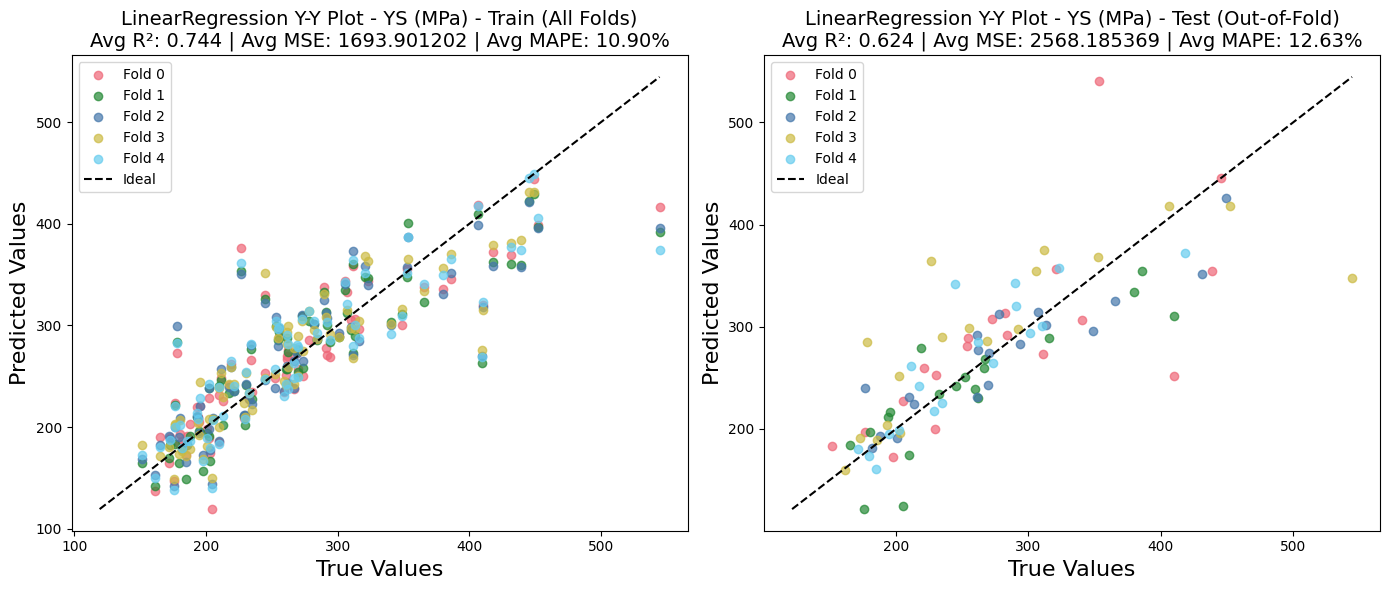

[I 2026-04-25 19:14:30,927] A new study created in memory with name: no-name-69aac6fb-2f0a-4695-842d-730fcb6aace4



--- Starting Workflow for: BayesianRidge ---

--- BayesianRidge - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:14:37,582] Trial 5 finished with values: [0.38511435208732425, 0.5143432534212484] and parameters: {'max_iter': 233, 'alpha_1': 4.3396580995987103e-07, 'alpha_2': 1.5974480182095852e-06, 'lambda_1': 2.248296984021607e-06, 'lambda_2': 1.0590195126719982e-06}.
[I 2026-04-25 19:14:37,658] Trial 6 finished with values: [0.38511435208732425, 0.5143432534212484] and parameters: {'max_iter': 450, 'alpha_1': 2.002954423649045e-06, 'alpha_2': 4.3562533229861315e-07, 'lambda_1': 7.99524928359342e-06, 'lambda_2': 5.5174176237732e-07}.
[I 2026-04-25 19:14:37,663] Trial 9 finished with values: [0.38511435208732425, 0.5143432534212484] and parameters: {'max_iter': 225, 'alpha_1': 5.197485969689853e-06, 'alpha_2': 1.9607862513186806e-06, 'lambda_1': 7.930156976157433e-07, 'lambda_2': 3.825781941591073e-06}.
[I 2026-04-25 19:14:37,719] Trial 14 finished with values: [0.38511435208732425, 0.5143432534212484] and parameters: {'max_iter': 306, 'alpha_1': 1.45521003247226e-07, 'alpha_2': 

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for BayesianRidge for YS (MPa) saved as PNGs in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- BayesianRidge - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- BayesianRidge - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
BayesianRidge_YS (MPa)_x_scaler_fold_0.pkl and BayesianRidge_YS (MPa)_y_scaler_fold_0.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.003 seconds.
Saving model for BayesianRidge from Fold 0...
Best model for BayesianRidge for YS (MPa) (Fold 0) saved to: YS_MPa_Results_v3_5_Fold_CV_GS_SD\models\BayesianRidge_YS (MPa)_best_model_fold_0.pkl

--- BayesianRidge - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
BayesianRidge_YS (MPa)_x_scaler_fold_1.pkl and BayesianRidge_YS (MPa)_y_scaler_fold_1.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best h

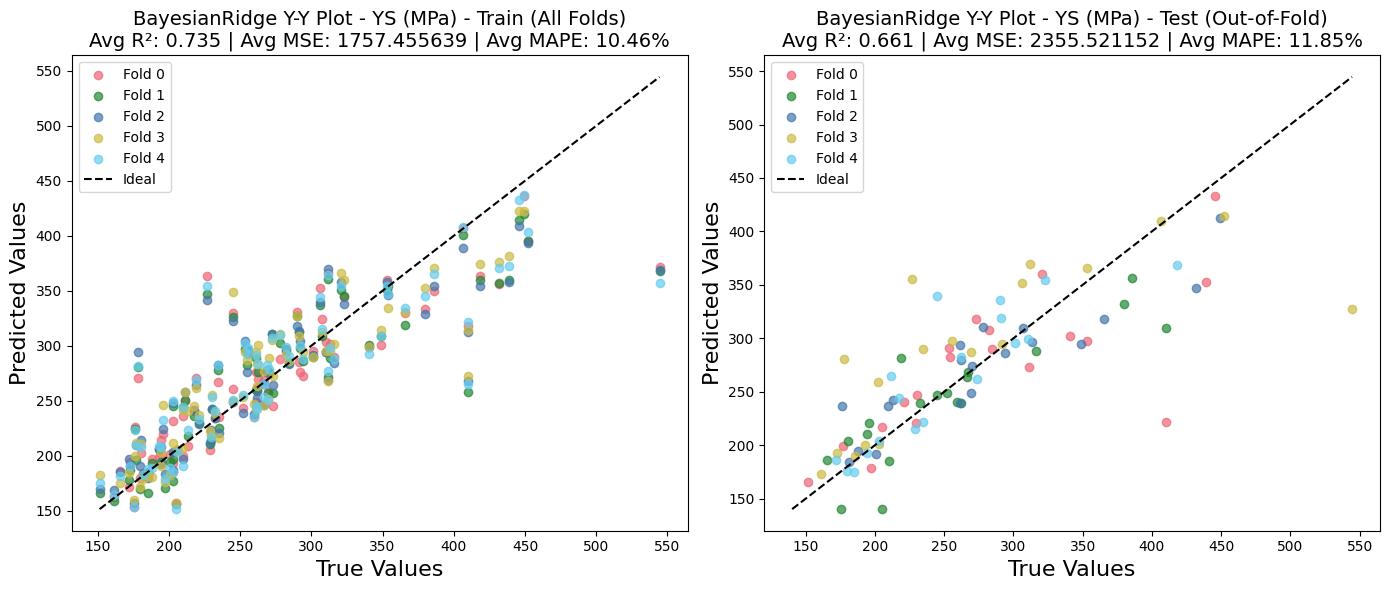

[I 2026-04-25 19:14:45,856] A new study created in memory with name: no-name-1fddc5bf-10ae-4626-97c5-e132d7c6934e



--- Starting Workflow for: SVR ---

--- SVR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:14:45,981] Trial 2 finished with values: [0.5212020050717324, 0.36727880471534385] and parameters: {'C': 40.14739123521853, 'gamma': 0.0033816029703024396, 'epsilon': 0.00314422921256154}.
[I 2026-04-25 19:14:45,986] Trial 0 finished with values: [0.45352930521381535, 0.42442060206044135] and parameters: {'C': 4.899450749113369, 'gamma': 0.00040062831551760996, 'epsilon': 0.0637709562958892}.
[I 2026-04-25 19:14:45,987] Trial 1 finished with values: [0.7731214370568757, 0.058104442952675785] and parameters: {'C': 132.34677008150143, 'gamma': 0.0008724042371629591, 'epsilon': 0.05378158414716386}.
[I 2026-04-25 19:14:46,024] Trial 6 finished with values: [0.5969588611308112, 0.2399827942917155] and parameters: {'C': 0.6800212768890357, 'gamma': 0.9162283851028847, 'epsilon': 0.004628153266969541}.
[I 2026-04-25 19:14:46,044] Trial 4 finished with values: [0.5969588611308112, 0.2399827942917155] and parameters: {'C': 16.768427922491146, 'gamma': 0.0013959828448653108, 'e

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for SVR for YS (MPa) saved as PNGs in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- SVR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- SVR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
SVR_YS (MPa)_x_scaler_fold_0.pkl and SVR_YS (MPa)_y_scaler_fold_0.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.001 seconds.
Saving model for SVR from Fold 0...
Best model for SVR for YS (MPa) (Fold 0) saved to: YS_MPa_Results_v3_5_Fold_CV_GS_SD\models\SVR_YS (MPa)_best_model_fold_0.pkl

--- SVR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
SVR_YS (MPa)_x_scaler_fold_1.pkl and SVR_YS (MPa)_y_scaler_fold_1.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.002 seconds.
Saving model for SVR from Fold 1...
Best mo

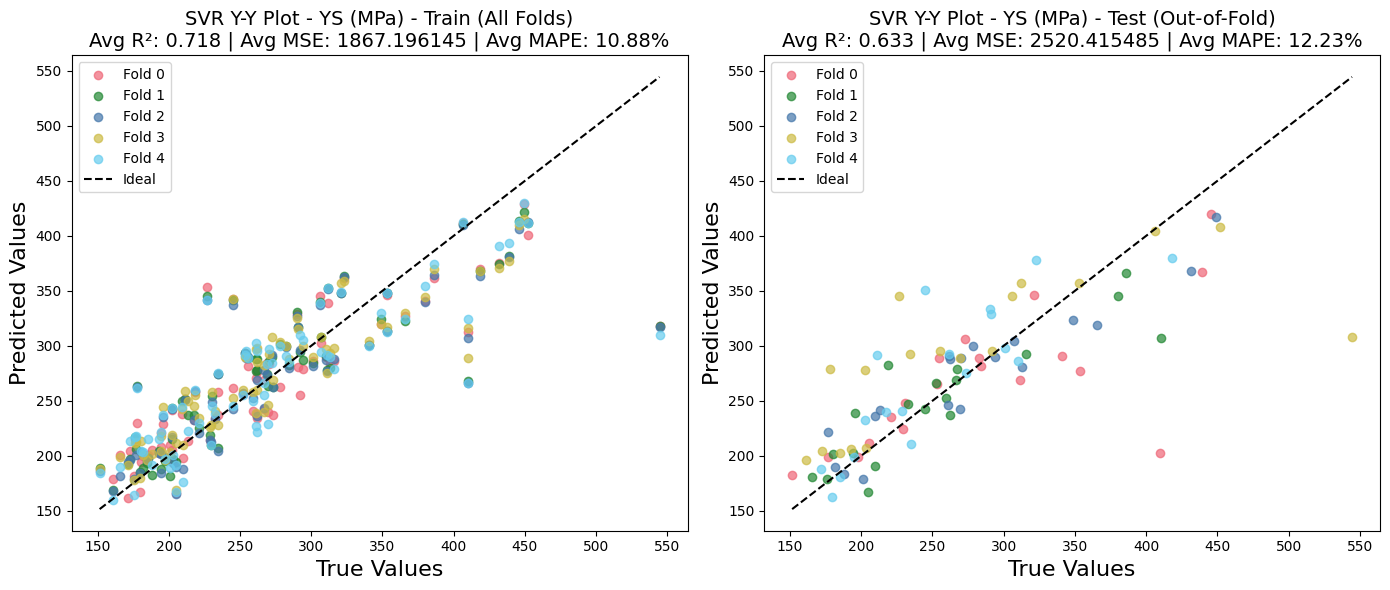

[I 2026-04-25 19:14:53,323] A new study created in memory with name: no-name-96b3908e-fbc0-4d6a-b4a1-4c17334eb95e



--- Starting Workflow for: DecisionTree ---

--- DecisionTree - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:14:53,673] Trial 0 finished with values: [0.7685082599359401, 0.07002145199212906] and parameters: {'max_depth': 49, 'min_samples_split': 8, 'min_samples_leaf': 8}.
[I 2026-04-25 19:14:53,704] Trial 2 finished with values: [0.8512818775419466, -0.14522600353751597] and parameters: {'max_depth': 5, 'min_samples_split': 15, 'min_samples_leaf': 12}.
[I 2026-04-25 19:14:53,707] Trial 6 finished with values: [0.6553823358357617, 0.09784508562308829] and parameters: {'max_depth': 11, 'min_samples_split': 12, 'min_samples_leaf': 1}.
[I 2026-04-25 19:14:53,707] Trial 7 finished with values: [0.9998555307114513, -0.3142541807179845] and parameters: {'max_depth': 44, 'min_samples_split': 3, 'min_samples_leaf': 8}.
[I 2026-04-25 19:14:53,707] Trial 8 finished with values: [0.9998555307114513, -0.3142541807179845] and parameters: {'max_depth': 22, 'min_samples_split': 11, 'min_samples_leaf': 6}.
[I 2026-04-25 19:14:53,708] Trial 12 finished with values: [0.9998555307114513, -0.314

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for DecisionTree for YS (MPa) saved as PNGs in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- DecisionTree - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- DecisionTree - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
DecisionTree_YS (MPa)_x_scaler_fold_0.pkl and DecisionTree_YS (MPa)_y_scaler_fold_0.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.001 seconds.
Saving model for DecisionTree from Fold 0...
Best model for DecisionTree for YS (MPa) (Fold 0) saved to: YS_MPa_Results_v3_5_Fold_CV_GS_SD\models\DecisionTree_YS (MPa)_best_model_fold_0.pkl

--- DecisionTree - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
DecisionTree_YS (MPa)_x_scaler_fold_1.pkl and DecisionTree_YS (MPa)_y_scaler_fold_1.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparamet

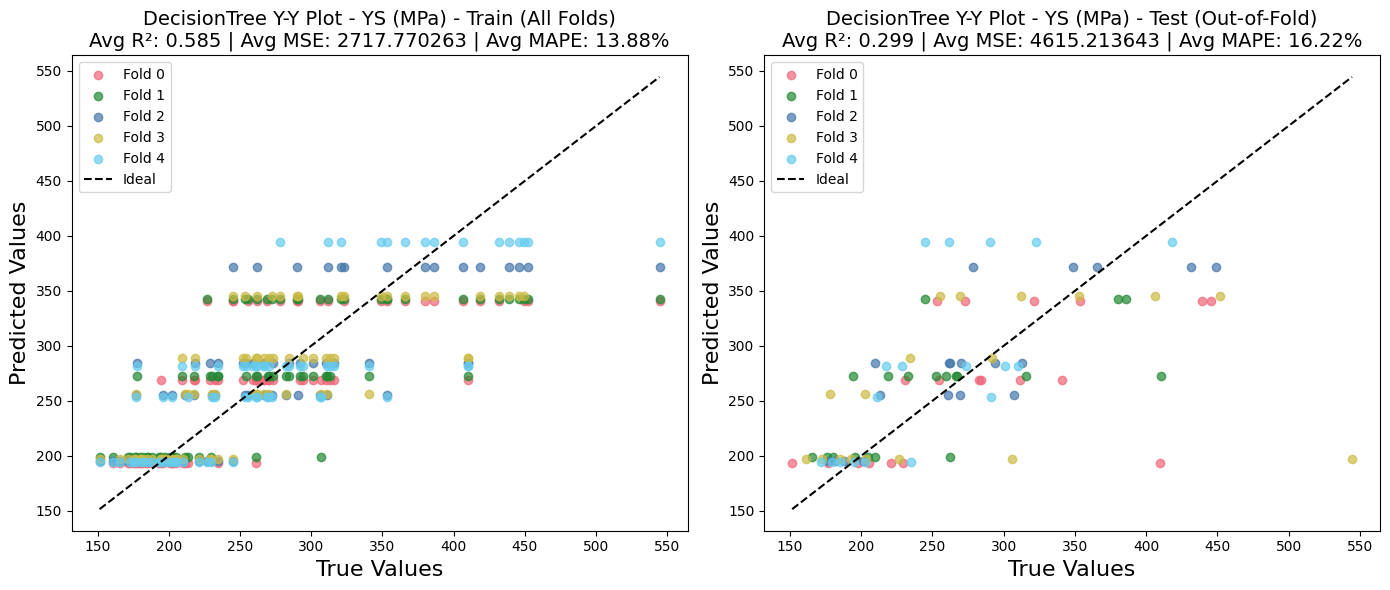

[I 2026-04-25 19:14:59,881] A new study created in memory with name: no-name-d9a42d55-1a02-4aba-a2b8-206fbbe8490d



--- Starting Workflow for: RandomForest ---

--- RandomForest - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:15:00,253] Trial 1 finished with values: [0.5462876539606585, 0.3126734505665662] and parameters: {'n_estimators': 68, 'max_depth': 50, 'min_samples_split': 8, 'min_samples_leaf': 7}.
[I 2026-04-25 19:15:00,993] Trial 0 finished with values: [0.5519632687328724, 0.3209596952753518] and parameters: {'n_estimators': 68, 'max_depth': 50, 'min_samples_split': 8, 'min_samples_leaf': 4}.
[I 2026-04-25 19:15:00,997] Trial 7 finished with values: [0.5772604130586089, 0.269923429728009] and parameters: {'n_estimators': 166, 'max_depth': 34, 'min_samples_split': 13, 'min_samples_leaf': 7}.
[I 2026-04-25 19:15:01,222] Trial 3 finished with values: [0.5519632687328724, 0.3209596952753518] and parameters: {'n_estimators': 114, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 8}.
[I 2026-04-25 19:15:01,348] Trial 6 finished with values: [0.5772604130586089, 0.269923429728009] and parameters: {'n_estimators': 170, 'max_depth': 27, 'min_samples_split': 7, 'min_samples_lea

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for RandomForest for YS (MPa) saved as PNGs in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- RandomForest - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- RandomForest - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
RandomForest_YS (MPa)_x_scaler_fold_0.pkl and RandomForest_YS (MPa)_y_scaler_fold_0.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.148 seconds.
Saving model for RandomForest from Fold 0...
Best model for RandomForest for YS (MPa) (Fold 0) saved to: YS_MPa_Results_v3_5_Fold_CV_GS_SD\models\RandomForest_YS (MPa)_best_model_fold_0.pkl

--- RandomForest - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
RandomForest_YS (MPa)_x_scaler_fold_1.pkl and RandomForest_YS (MPa)_y_scaler_fold_1.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparamet

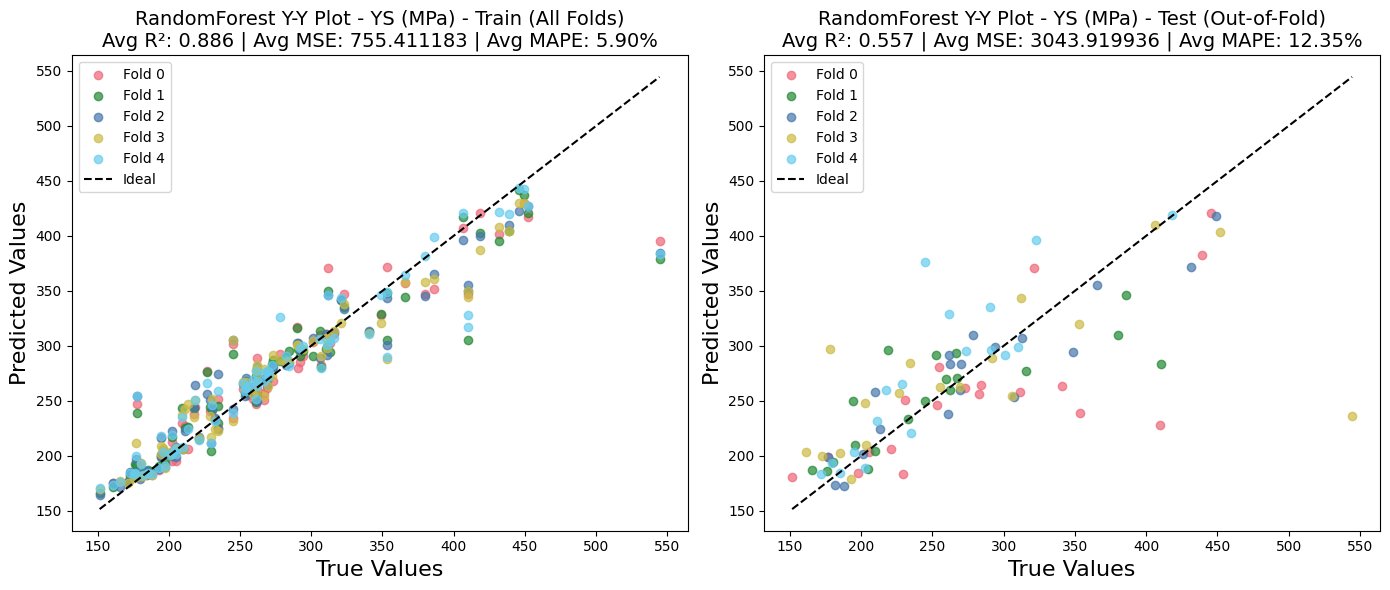

[I 2026-04-25 19:15:14,564] A new study created in memory with name: no-name-895fdd56-6a64-401a-ad90-24aa018f0d1a



--- Starting Workflow for: XGBoost ---

--- XGBoost - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:15:16,671] Trial 1 finished with values: [0.5532151033247522, 0.3168722097726369] and parameters: {'n_estimators': 161, 'learning_rate': 0.017130578933730167, 'max_depth': 4, 'subsample': 0.7759487525974905, 'colsample_bytree': 0.6449093603907837}.
[I 2026-04-25 19:15:16,693] Trial 10 finished with values: [0.4629263275549992, 0.41716845251574836] and parameters: {'n_estimators': 165, 'learning_rate': 0.0460318274052529, 'max_depth': 10, 'subsample': 0.6732714505946772, 'colsample_bytree': 0.7279249912197276}.
[I 2026-04-25 19:15:16,720] Trial 0 finished with values: [0.45067828100001356, 0.4478774873532938] and parameters: {'n_estimators': 159, 'learning_rate': 0.021085871975614633, 'max_depth': 8, 'subsample': 0.6225188286451395, 'colsample_bytree': 0.9047288475161277}.
[I 2026-04-25 19:15:16,799] Trial 8 finished with values: [0.4629263275549992, 0.41716845251574836] and parameters: {'n_estimators': 84, 'learning_rate': 0.046051168635716226, 'max_depth': 10, 'subsam

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for XGBoost for YS (MPa) saved as PNGs in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- XGBoost - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- XGBoost - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
XGBoost_YS (MPa)_x_scaler_fold_0.pkl and XGBoost_YS (MPa)_y_scaler_fold_0.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.137 seconds.
Saving model for XGBoost from Fold 0...
Best model for XGBoost for YS (MPa) (Fold 0) saved to: YS_MPa_Results_v3_5_Fold_CV_GS_SD\models\XGBoost_YS (MPa)_best_model_fold_0.pkl

--- XGBoost - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
XGBoost_YS (MPa)_x_scaler_fold_1.pkl and XGBoost_YS (MPa)_y_scaler_fold_1.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.026 seconds.

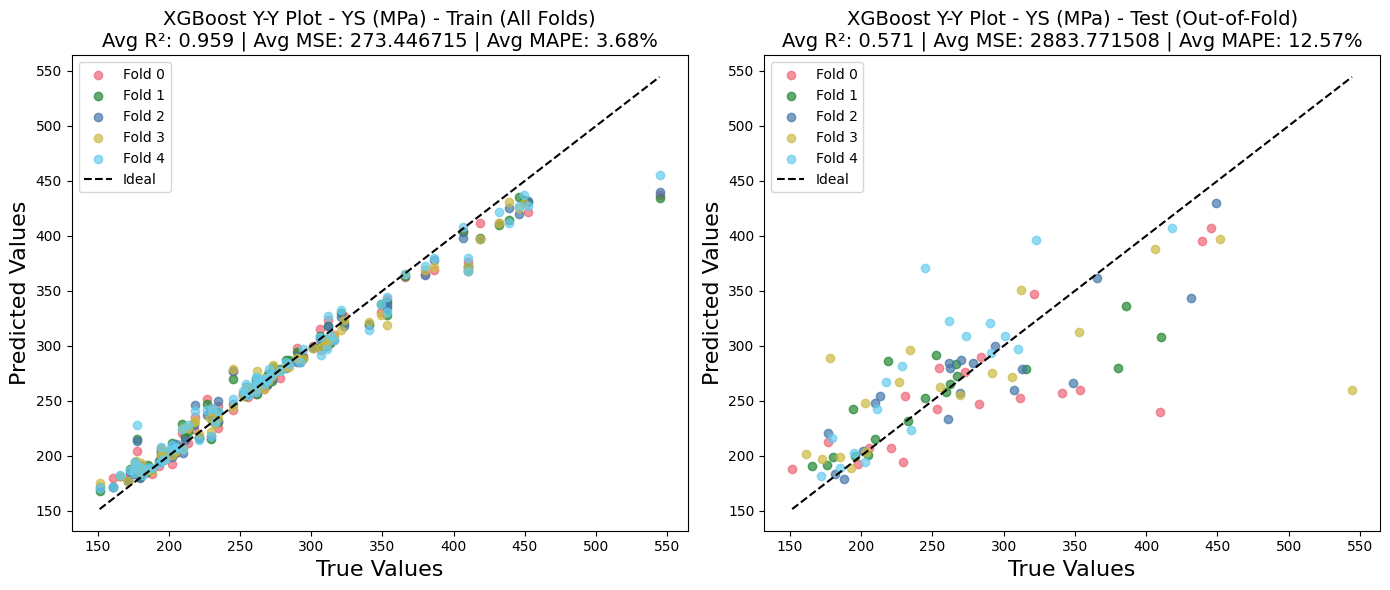

[I 2026-04-25 19:15:25,533] A new study created in memory with name: no-name-9813700d-5f5f-4241-bcac-d02cb9993fd8



--- Starting Workflow for: GPR ---

--- GPR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Using n_jobs=1 for GaussianProcessRegressor to manage high memory usage.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:15:25,669] Trial 0 finished with values: [0.4268547189954214, 0.47539857223409676] and parameters: {'kernel': 'Matern_nu_0.5', 'alpha': 2.534840766433346e-09}.
[I 2026-04-25 19:15:25,762] Trial 1 finished with values: [0.4101229199581457, 0.49190900739710275] and parameters: {'kernel': 'Matern_nu_0.5', 'alpha': 0.05360294728728273}.
[I 2026-04-25 19:15:25,886] Trial 2 finished with values: [0.8329650049844654, -0.017246071847953747] and parameters: {'kernel': 'RBF_default', 'alpha': 5.282115394532298e-06}.
[I 2026-04-25 19:15:26,010] Trial 3 finished with values: [0.8314220420810787, -0.01568945015484251] and parameters: {'kernel': 'Matern_nu_1.5', 'alpha': 1.9826980964985952e-07}.
[I 2026-04-25 19:15:26,103] Trial 4 finished with values: [0.42685472747805286, 0.4753985642141485] and parameters: {'kernel': 'Matern_nu_0.5', 'alpha': 2.6185068507773743e-10}.
[I 2026-04-25 19:15:26,305] Trial 5 finished with values: [0.5210509748433181, 0.36569755693822825] and parameters

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for GPR for YS (MPa) saved as PNGs in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- GPR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- GPR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
GPR_YS (MPa)_x_scaler_fold_0.pkl and GPR_YS (MPa)_y_scaler_fold_0.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.057 seconds.
Saving model for GPR from Fold 0...
Best model for GPR for YS (MPa) (Fold 0) saved to: YS_MPa_Results_v3_5_Fold_CV_GS_SD\models\GPR_YS (MPa)_best_model_fold_0.pkl

--- GPR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
GPR_YS (MPa)_x_scaler_fold_1.pkl and GPR_YS (MPa)_y_scaler_fold_1.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.089 seconds.
Saving model for GPR from Fold 1...
Best mo

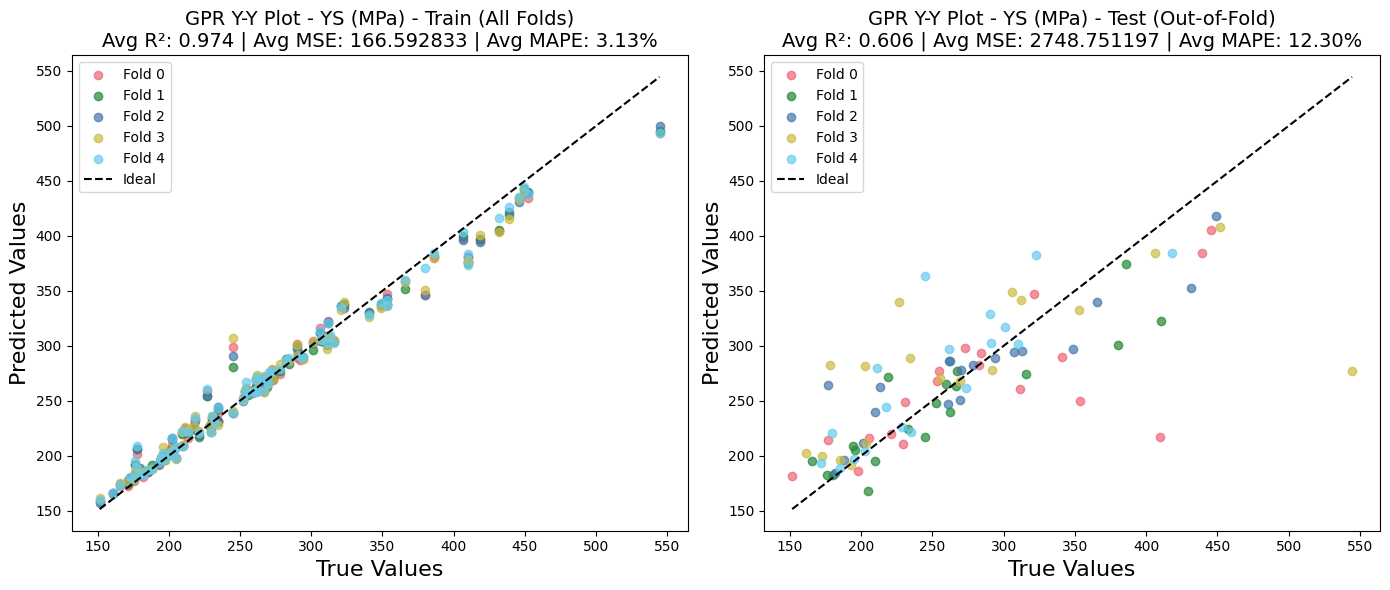

[I 2026-04-25 19:15:42,798] A new study created in memory with name: no-name-4f870129-d916-4135-bf15-a00414918ca6



--- Starting Workflow for: NNR ---

--- NNR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Using n_jobs=1 for Neural Network to ensure GPU stability.


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 0s 47ms/step
[I 2026-04-25 19:16:05,569] Trial 0 finished with values: [0.48469791119994, 0.5467798596672804] and parameters: {'hidden_layers': 2, 'units': 124, 'activation': 'relu', 'learning_rate': 2.9375384576328295e-05}.
1/1 [==============================] - 0s 37ms/step
[I 2026-04-25 19:16:19,075] Trial 1 finished with values: [0.5122962178684418, 0.4632355974489496] and parameters: {'hidden_layers': 1, 'units': 116, 'activation': 'tanh', 'learning_rate': 0.008123245085588688}.
1/1 [==============================] - 0s 53ms/step
[I 2026-04-25 19:16:36,093] Trial 2 finished with values: [0.6260545100795885, 0.3762456089462238] and parameters: {'hidden_layers': 4, 'units': 52, 'activation': 'selu', 'learning_rate': 0.00037520558551242813}.
1/1 [==============================] - 0s 43ms/step
[I 2026-04-25 19:16:51,331] Trial 3 finished with values: [0.5308519149829929, 0.49487522119304916] and parameters: {'hidden_layers': 2, 'units': 60, 'acti

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for NNR for YS (MPa) saved as PNGs in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- NNR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- NNR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
NNR_YS (MPa)_x_scaler_fold_0.pkl and NNR_YS (MPa)_y_scaler_fold_0.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 2.627 seconds.
1/1 [==============================] - 0s 17ms/step
Saving model for NNR from Fold 0...
Best model for NNR for YS (MPa) (Fold 0) saved to: YS_MPa_Results_v3_5_Fold_CV_GS_SD\models\NNR_YS (MPa)_best_model_fold_0.keras

--- NNR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
NNR_YS (MPa)_x_scaler_fold_1.pkl and NNR_YS (MPa)_y_scaler_fold_1.pkl saved in 'YS_MPa_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 2.51

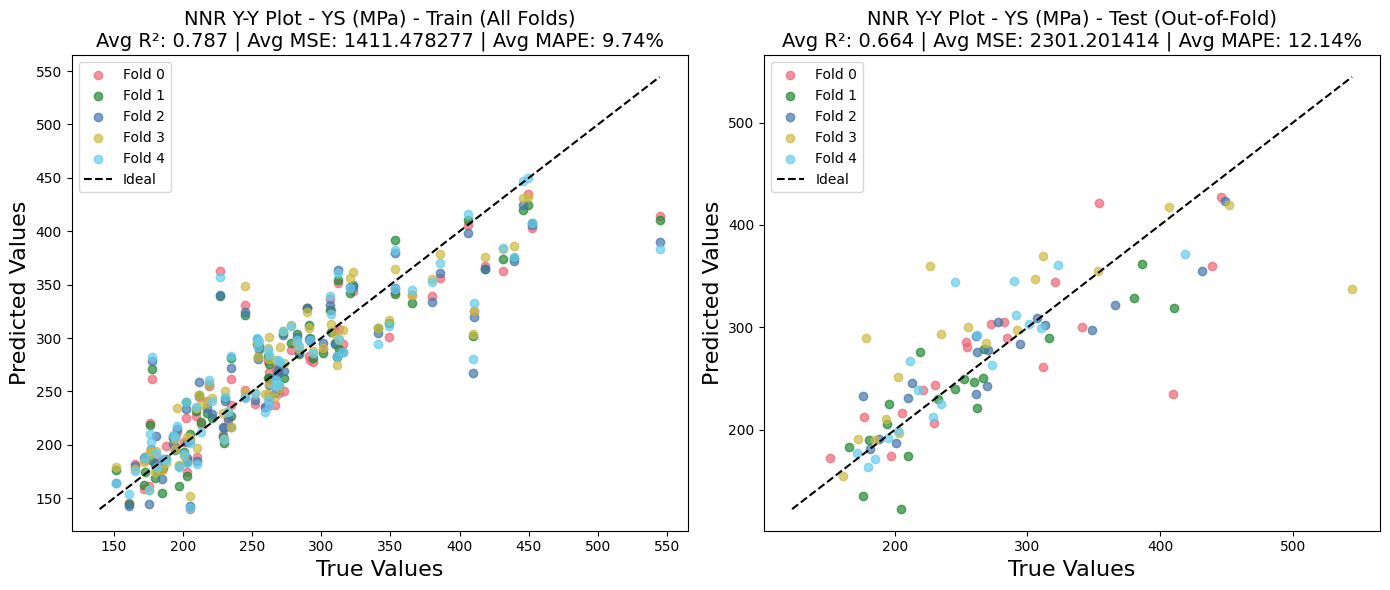


--- Workflow Complete ---
Final 5-fold CV results summary for YS (MPa) saved to YS_MPa_Results_v3_5_Fold_CV_GS_SD\YS (MPa)_results_5_fold_CV.csv

============================== Completed Workflow for: YS (MPa) ==============================


============================== Processing Target: Hardness, HV ==============================
All outputs will be saved to: 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD' folder.
Initializing Pre-Optimization CV workflow for target: 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD'...
Setting up directories...

--- Starting Workflow for: LinearRegression ---

--- LinearRegression - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
No hyperparameters defined. Returning default settings.

--- LinearRegression - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- LinearRegression - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
LinearRegressio

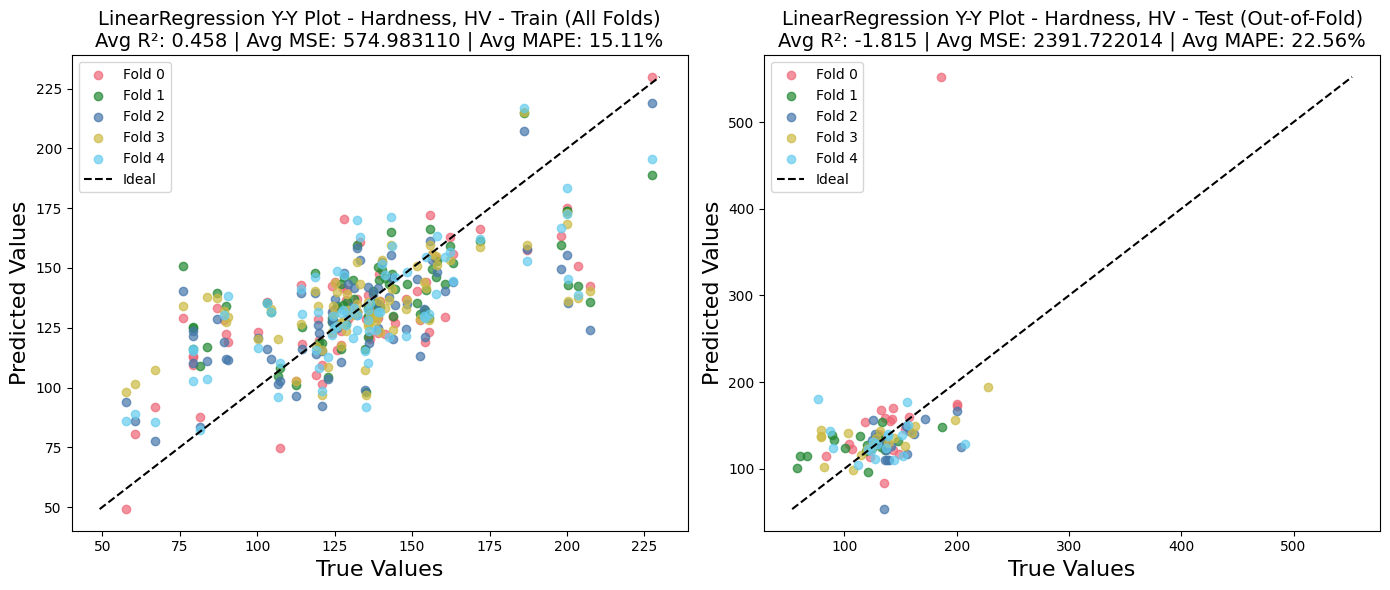

[I 2026-04-25 19:40:00,416] A new study created in memory with name: no-name-ea186f52-5ac4-4863-a21c-332a5b246db8



--- Starting Workflow for: BayesianRidge ---

--- BayesianRidge - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:40:06,478] Trial 4 finished with values: [1.7685810813440597, -2.3536160535658657] and parameters: {'max_iter': 484, 'alpha_1': 2.5707659477632024e-06, 'alpha_2': 6.33545513620507e-07, 'lambda_1': 5.859348934138351e-06, 'lambda_2': 2.3571376514528305e-07}.
[I 2026-04-25 19:40:06,509] Trial 0 finished with values: [1.7685804052514826, -2.353615224917032] and parameters: {'max_iter': 246, 'alpha_1': 1.169728313086453e-06, 'alpha_2': 1.4990310988326342e-07, 'lambda_1': 5.187272020825108e-06, 'lambda_2': 4.788616687954891e-07}.
[I 2026-04-25 19:40:06,524] Trial 11 finished with values: [1.7685810813440597, -2.3536160535658657] and parameters: {'max_iter': 226, 'alpha_1': 9.168696355785424e-06, 'alpha_2': 6.430512271945052e-07, 'lambda_1': 2.0530782511671945e-07, 'lambda_2': 4.4497674571424116e-07}.
[I 2026-04-25 19:40:06,528] Trial 10 finished with values: [1.7685810813440597, -2.3536160535658657] and parameters: {'max_iter': 445, 'alpha_1': 1.1008247079465021e-07, 'alpha_

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for BayesianRidge for Hardness, HV saved as PNGs in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- BayesianRidge - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- BayesianRidge - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
BayesianRidge_Hardness, HV_x_scaler_fold_0.pkl and BayesianRidge_Hardness, HV_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.003 seconds.
Saving model for BayesianRidge from Fold 0...
Best model for BayesianRidge for Hardness, HV (Fold 0) saved to: Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models\BayesianRidge_Hardness, HV_best_model_fold_0.pkl

--- BayesianRidge - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
BayesianRidge_Hardness, HV_x_scaler_fold_1.pkl and BayesianRidge_Hardness, HV_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\mod

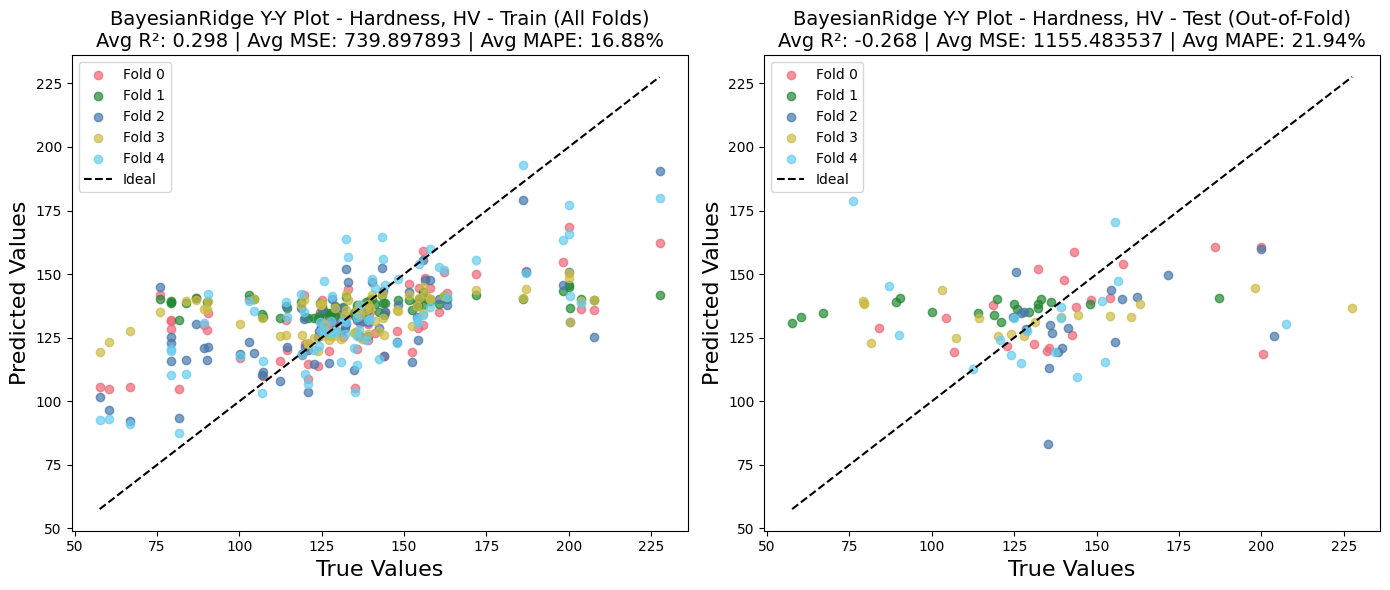

[I 2026-04-25 19:40:13,456] A new study created in memory with name: no-name-dc1c8798-9f0e-4385-9677-6ce80b318cc2



--- Starting Workflow for: SVR ---

--- SVR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:40:13,567] Trial 0 finished with values: [1.6558474385125863, -2.0798783750265493] and parameters: {'C': 1.0984271082268362, 'gamma': 0.3445314573177255, 'epsilon': 0.007598344627148074}.
[I 2026-04-25 19:40:13,598] Trial 1 finished with values: [1.1343759056129368, -1.093162982888097] and parameters: {'C': 5100.756304477173, 'gamma': 0.0005931333698263004, 'epsilon': 0.3951174179769321}.
[I 2026-04-25 19:40:13,614] Trial 2 finished with values: [1.2757839009087515, -1.3853910476094176] and parameters: {'C': 1928.488790907403, 'gamma': 0.6354385565662173, 'epsilon': 0.0014929223074797533}.
[I 2026-04-25 19:40:13,630] Trial 3 finished with values: [1.2757839009087515, -1.3853910476094176] and parameters: {'C': 30.90979344319082, 'gamma': 0.01851340877422732, 'epsilon': 0.001714043962046503}.
[I 2026-04-25 19:40:13,646] Trial 4 finished with values: [1.2757839009087515, -1.3853910476094176] and parameters: {'C': 2.101194917477923, 'gamma': 0.00028948149477238817, 'epsilo

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for SVR for Hardness, HV saved as PNGs in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- SVR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- SVR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
SVR_Hardness, HV_x_scaler_fold_0.pkl and SVR_Hardness, HV_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.000 seconds.
Saving model for SVR from Fold 0...
Best model for SVR for Hardness, HV (Fold 0) saved to: Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models\SVR_Hardness, HV_best_model_fold_0.pkl

--- SVR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
SVR_Hardness, HV_x_scaler_fold_1.pkl and SVR_Hardness, HV_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.001 seco

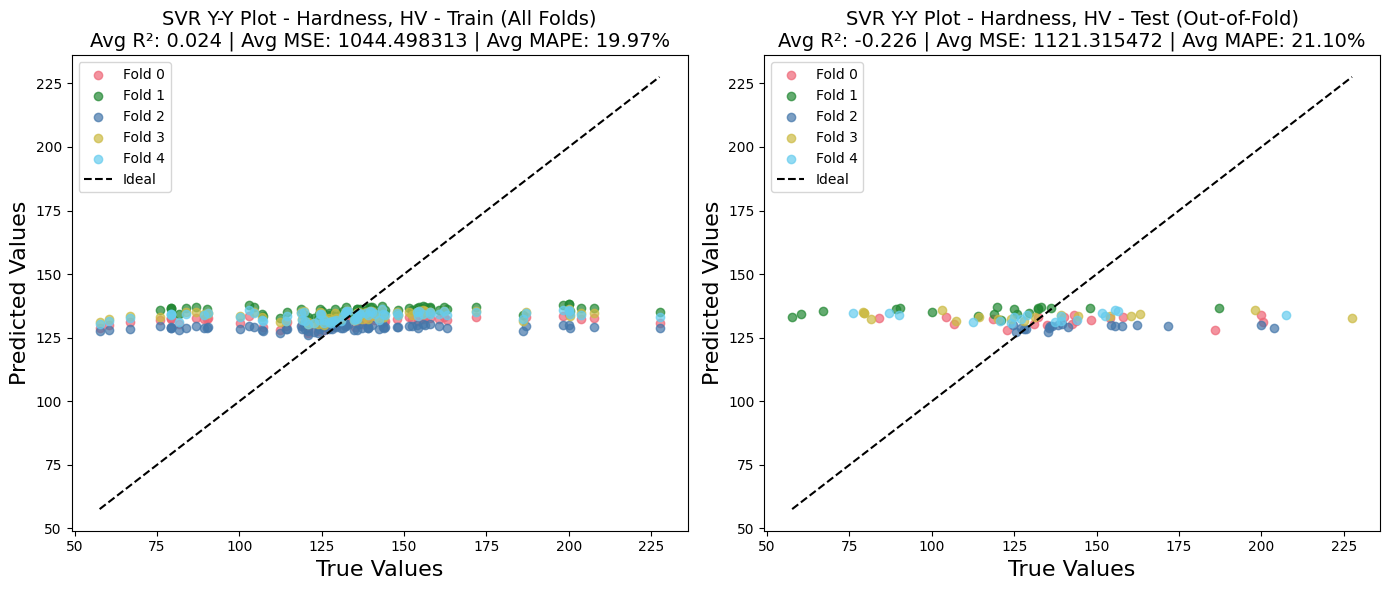

[I 2026-04-25 19:40:19,927] A new study created in memory with name: no-name-67e5ad77-9907-42de-82d3-3f329cb0c697



--- Starting Workflow for: DecisionTree ---

--- DecisionTree - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:40:20,184] Trial 2 finished with values: [1.9225435111483216, -2.681135077762539] and parameters: {'max_depth': 33, 'min_samples_split': 6, 'min_samples_leaf': 2}.
[I 2026-04-25 19:40:20,187] Trial 0 finished with values: [2.533399043246761, -3.7818974198258717] and parameters: {'max_depth': 28, 'min_samples_split': 8, 'min_samples_leaf': 4}.
[I 2026-04-25 19:40:20,188] Trial 3 finished with values: [3.0976757556658185, -4.8159520914258165] and parameters: {'max_depth': 39, 'min_samples_split': 6, 'min_samples_leaf': 14}.
[I 2026-04-25 19:40:20,189] Trial 1 finished with values: [2.533399043246761, -3.7818974198258717] and parameters: {'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 14}.
[I 2026-04-25 19:40:20,232] Trial 4 finished with values: [1.7035205255575303, -2.32157967986649] and parameters: {'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 15}.
[I 2026-04-25 19:40:20,249] Trial 13 finished with values: [1.7579972223276166, -2.3794302800

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for DecisionTree for Hardness, HV saved as PNGs in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- DecisionTree - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- DecisionTree - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
DecisionTree_Hardness, HV_x_scaler_fold_0.pkl and DecisionTree_Hardness, HV_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.001 seconds.
Saving model for DecisionTree from Fold 0...
Best model for DecisionTree for Hardness, HV (Fold 0) saved to: Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models\DecisionTree_Hardness, HV_best_model_fold_0.pkl

--- DecisionTree - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
DecisionTree_Hardness, HV_x_scaler_fold_1.pkl and DecisionTree_Hardness, HV_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retra

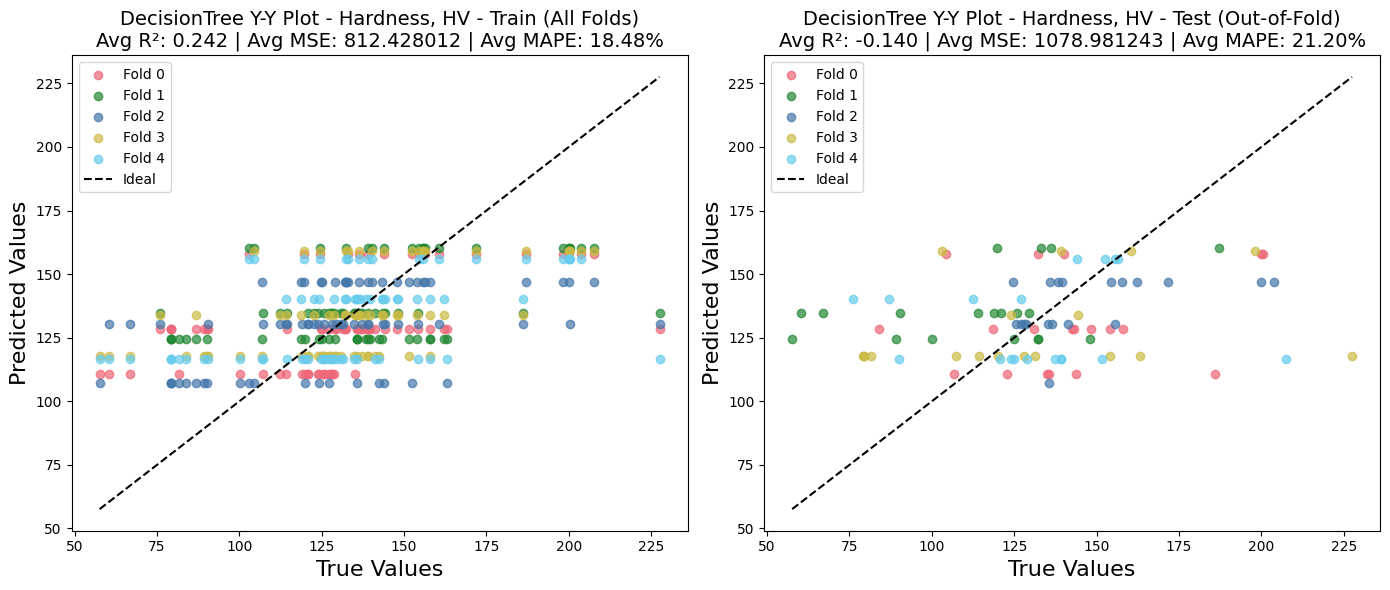

[I 2026-04-25 19:40:25,714] A new study created in memory with name: no-name-4e9e28ec-0e92-442c-af02-abe2eefcb0fa



--- Starting Workflow for: RandomForest ---

--- RandomForest - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:40:26,086] Trial 0 finished with values: [1.5604702076656802, -1.974037427026614] and parameters: {'n_estimators': 97, 'max_depth': 24, 'min_samples_split': 19, 'min_samples_leaf': 3}.
[I 2026-04-25 19:40:26,245] Trial 2 finished with values: [1.6603696847960472, -2.1572190341528144] and parameters: {'n_estimators': 186, 'max_depth': 40, 'min_samples_split': 17, 'min_samples_leaf': 7}.
[I 2026-04-25 19:40:26,351] Trial 3 finished with values: [1.7988833401759738, -2.4293476961867033] and parameters: {'n_estimators': 134, 'max_depth': 21, 'min_samples_split': 19, 'min_samples_leaf': 3}.
[I 2026-04-25 19:40:26,355] Trial 4 finished with values: [1.7988833401759738, -2.4293476961867033] and parameters: {'n_estimators': 149, 'max_depth': 14, 'min_samples_split': 16, 'min_samples_leaf': 2}.
[I 2026-04-25 19:40:26,398] Trial 1 finished with values: [1.719596320591578, -2.2392079039794828] and parameters: {'n_estimators': 53, 'max_depth': 20, 'min_samples_split': 2, 'min_samp

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for RandomForest for Hardness, HV saved as PNGs in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- RandomForest - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- RandomForest - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
RandomForest_Hardness, HV_x_scaler_fold_0.pkl and RandomForest_Hardness, HV_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.154 seconds.
Saving model for RandomForest from Fold 0...
Best model for RandomForest for Hardness, HV (Fold 0) saved to: Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models\RandomForest_Hardness, HV_best_model_fold_0.pkl

--- RandomForest - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
RandomForest_Hardness, HV_x_scaler_fold_1.pkl and RandomForest_Hardness, HV_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retra

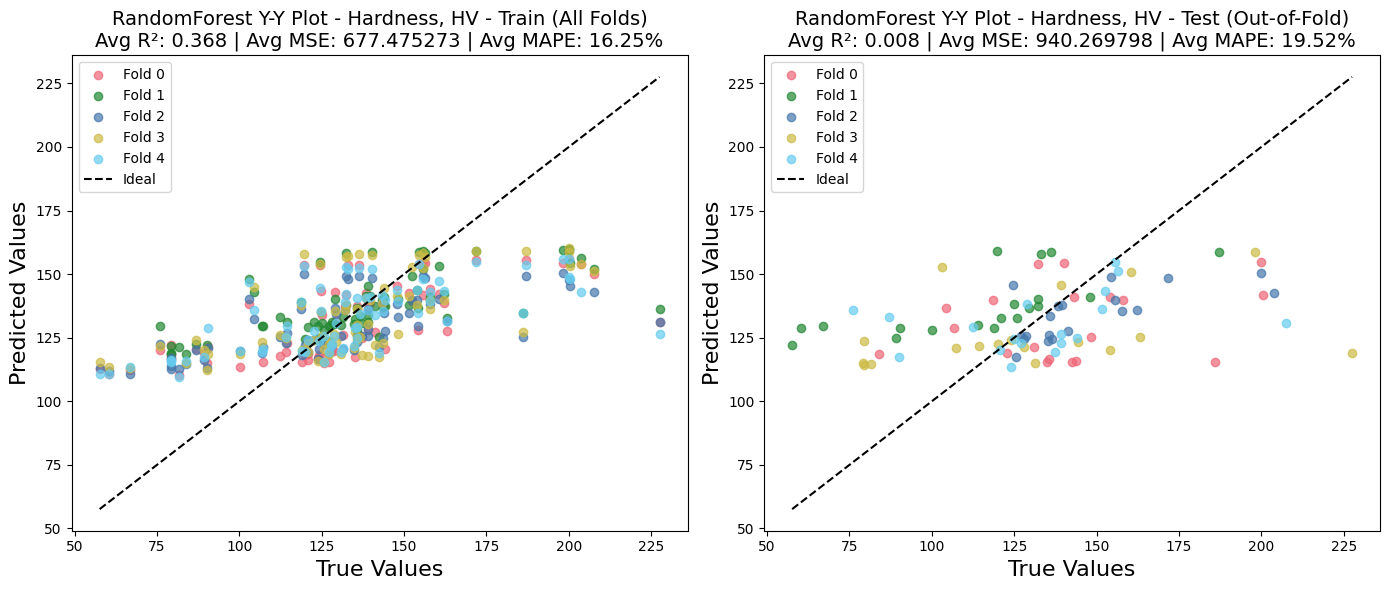

[I 2026-04-25 19:40:43,877] A new study created in memory with name: no-name-7ff34228-36a3-4e52-a001-52bea047cf1f



--- Starting Workflow for: XGBoost ---

--- XGBoost - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:40:45,594] Trial 6 finished with values: [2.2138525510429505, -3.345932521858509] and parameters: {'n_estimators': 167, 'learning_rate': 0.012636719763701766, 'max_depth': 8, 'subsample': 0.8231647401729252, 'colsample_bytree': 0.8847038837784815}.
[I 2026-04-25 19:40:45,613] Trial 9 finished with values: [2.2138525510429505, -3.345932521858509] and parameters: {'n_estimators': 117, 'learning_rate': 0.11670452007747596, 'max_depth': 9, 'subsample': 0.9365830001682373, 'colsample_bytree': 0.6275413805702018}.
[I 2026-04-25 19:40:45,644] Trial 7 finished with values: [2.01091878186681, -2.9376245061293647] and parameters: {'n_estimators': 129, 'learning_rate': 0.1309756581078791, 'max_depth': 3, 'subsample': 0.8667642763257988, 'colsample_bytree': 0.6877286128843932}.
[I 2026-04-25 19:40:45,720] Trial 12 finished with values: [1.623305781460487, -2.1040411959834584] and parameters: {'n_estimators': 200, 'learning_rate': 0.11115349823812877, 'max_depth': 3, 'subsample': 0

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for XGBoost for Hardness, HV saved as PNGs in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- XGBoost - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- XGBoost - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
XGBoost_Hardness, HV_x_scaler_fold_0.pkl and XGBoost_Hardness, HV_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.081 seconds.
Saving model for XGBoost from Fold 0...
Best model for XGBoost for Hardness, HV (Fold 0) saved to: Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models\XGBoost_Hardness, HV_best_model_fold_0.pkl

--- XGBoost - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
XGBoost_Hardness, HV_x_scaler_fold_1.pkl and XGBoost_Hardness, HV_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...


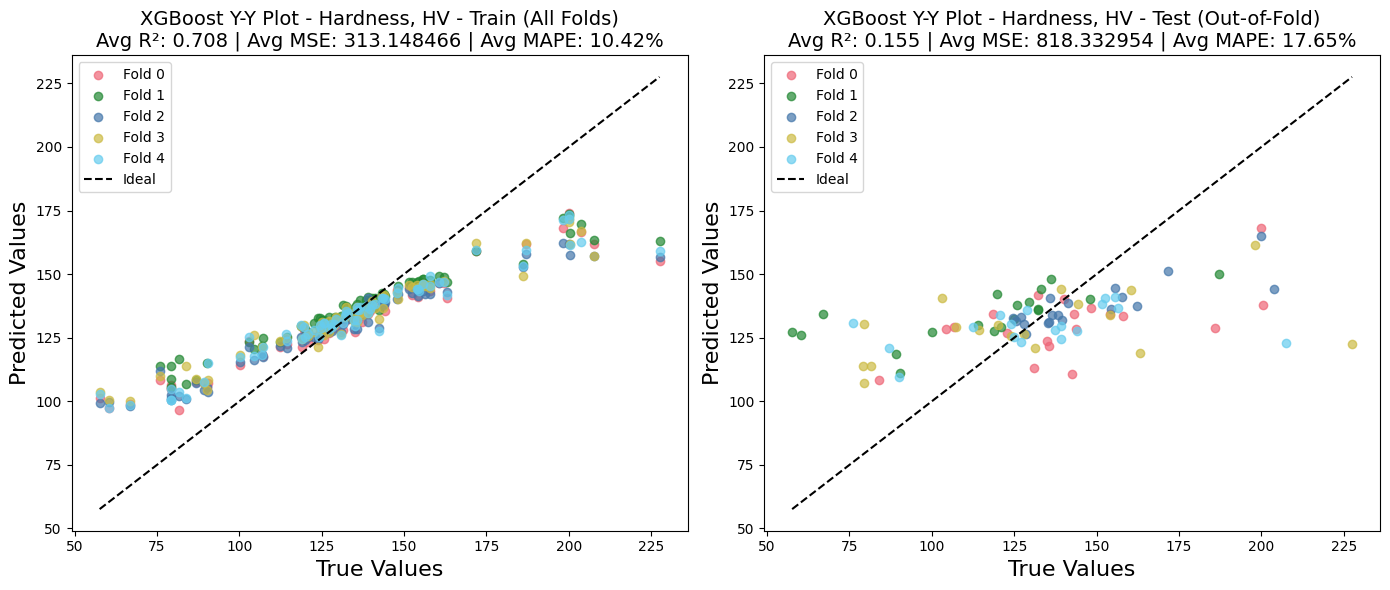

[I 2026-04-25 19:42:48,253] A new study created in memory with name: no-name-eba661ca-9c83-4c99-95e7-15bcf1dfea91



--- Starting Workflow for: GPR ---

--- GPR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Using n_jobs=1 for GaussianProcessRegressor to manage high memory usage.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-25 19:42:48,421] Trial 0 finished with values: [1.7444999268785168, -2.349183551506815] and parameters: {'kernel': 'Matern_nu_0.5', 'alpha': 2.534840766433346e-09}.
[I 2026-04-25 19:42:48,545] Trial 1 finished with values: [1.7184704241349742, -2.2969091251621636] and parameters: {'kernel': 'Matern_nu_0.5', 'alpha': 0.05360294728728273}.
[I 2026-04-25 19:42:48,701] Trial 2 finished with values: [1.8637271708620058, -2.593402889491229] and parameters: {'kernel': 'RBF_default', 'alpha': 5.282115394532298e-06}.
[I 2026-04-25 19:42:48,874] Trial 3 finished with values: [1.8012313274203176, -2.4589458211740336] and parameters: {'kernel': 'Matern_nu_1.5', 'alpha': 1.9826980964985952e-07}.
[I 2026-04-25 19:42:48,996] Trial 4 finished with values: [1.7444999289270107, -2.349183555134143] and parameters: {'kernel': 'Matern_nu_0.5', 'alpha': 2.6185068507773743e-10}.
[I 2026-04-25 19:42:49,324] Trial 5 finished with values: [1.8311904416051608, -2.5161431574530555] and parameters: {'ke

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for GPR for Hardness, HV saved as PNGs in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- GPR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- GPR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
GPR_Hardness, HV_x_scaler_fold_0.pkl and GPR_Hardness, HV_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 0.048 seconds.
Saving model for GPR from Fold 0...
Best model for GPR for Hardness, HV (Fold 0) saved to: Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models\GPR_Hardness, HV_best_model_fold_0.pkl

--- GPR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
GPR_Hardness, HV_x_scaler_fold_1.pkl and GPR_Hardness, HV_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 1 model training complete in 0.125 seco

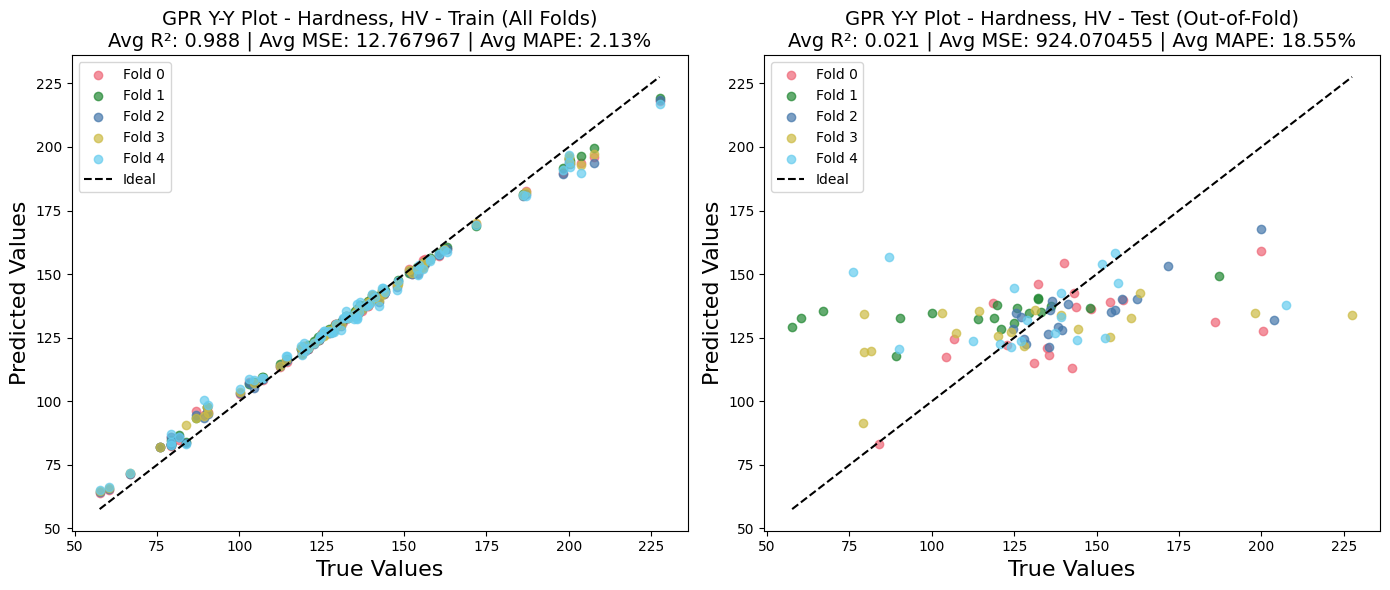

[I 2026-04-25 19:43:10,597] A new study created in memory with name: no-name-e96c3339-c1c0-4616-bb02-28ef2cf02f7f



--- Starting Workflow for: NNR ---

--- NNR - Step 1: Finding Best Hyperparameters (on 100% data) ---
Scalers (fit on 100% data) saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Using n_jobs=1 for Neural Network to ensure GPU stability.


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 [==============================] - 0s 45ms/step
[I 2026-04-25 19:43:25,461] Trial 0 finished with values: [1.0025010984883251, -0.15261825027038572] and parameters: {'hidden_layers': 2, 'units': 124, 'activation': 'relu', 'learning_rate': 2.9375384576328295e-05}.
1/1 [==============================] - 0s 40ms/step
[I 2026-04-25 19:43:39,301] Trial 1 finished with values: [1.3737023402557333, -0.71708065665208] and parameters: {'hidden_layers': 1, 'units': 116, 'activation': 'tanh', 'learning_rate': 0.008123245085588688}.
1/1 [==============================] - 0s 58ms/step
[I 2026-04-25 19:43:56,144] Trial 2 finished with values: [0.8220129412808876, -0.0647960912735442] and parameters: {'hidden_layers': 4, 'units': 52, 'activation': 'selu', 'learning_rate': 0.00037520558551242813}.
1/1 [==============================] - 0s 45ms/step
[I 2026-04-25 19:44:10,947] Trial 3 finished with values: [0.8133579860812518, 0.06251377572395697] and parameters: {'hidden_layers': 2, 'units': 60, '

c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:283: ExperimentalWarning: optuna.visualization.matplotlib._pareto_front.plot_pareto_front is experimental (supported from v2.8.0). The interface can change in the future.
  ax = vis.plot_pareto_front(study, target_names=["MSE", "R-squared"])
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:290: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:299: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = vis.plot_optimization_history(
c:\Users\shakt\Documents\gitrepo\Grain-size-YS-HV-ARMOTE-CV\armote_cv.py:308: Experimenta

Optuna plots for NNR for Hardness, HV saved as PNGs in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\plots' directory.

--- NNR - Step 2: 5-Fold CV Final Evaluation (using best params) ---

--- NNR - Evaluation Fold 1/5 ---
Fitting scalers on Fold 1 training data...
NNR_Hardness, HV_x_scaler_fold_0.pkl and NNR_Hardness, HV_y_scaler_fold_0.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperparameters...
Fold 0 model training complete in 3.012 seconds.
1/1 [==============================] - 0s 18ms/step
Saving model for NNR from Fold 0...
Best model for NNR for Hardness, HV (Fold 0) saved to: Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models\NNR_Hardness, HV_best_model_fold_0.keras

--- NNR - Evaluation Fold 2/5 ---
Fitting scalers on Fold 2 training data...
NNR_Hardness, HV_x_scaler_fold_1.pkl and NNR_Hardness, HV_y_scaler_fold_1.pkl saved in 'Hardness_HV_Results_v3_5_Fold_CV_GS_SD\models'.
Retraining the final model with the best hyperpara

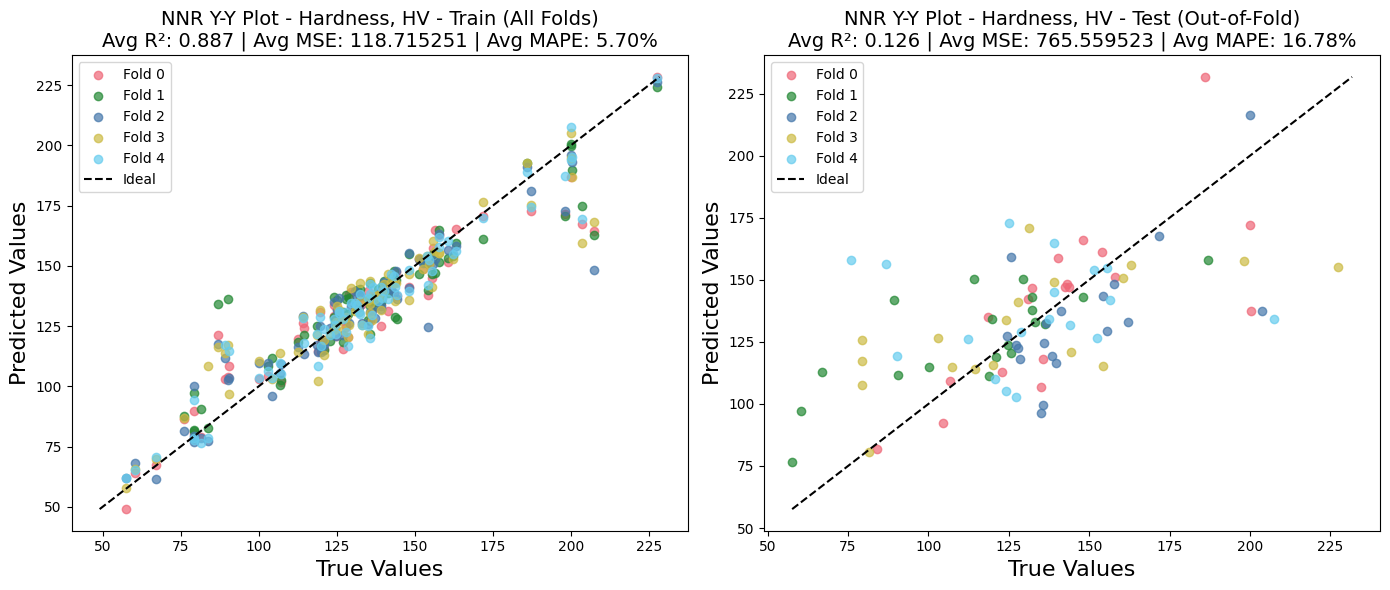


--- Workflow Complete ---
Final 5-fold CV results summary for Hardness, HV saved to Hardness_HV_Results_v3_5_Fold_CV_GS_SD\Hardness, HV_results_5_fold_CV.csv

============================== Completed Workflow for: Hardness, HV ==============================


ALL WORKFLOWS COMPLETE.


In [8]:
print("\n" + "="*80)
print("STARTING ALL WORKFLOWS")
print("="*80 + "\n")

for target_name in target_cols:
    print(f"\n{'='*30} Processing Target: {target_name} {'='*30}")
    
    # Select the current target column as a 1D array
    y_current = y_cleaned[target_name].values 
    
    # Sanitize the target name to create a valid folder name
    # "YS (MPa)" -> "YS_MPa_Results_v3"
    # "Hardness, HV" -> "Hardness_HV_Results_v3"
    output_folder_name = target_name.replace(' ', '_').replace('(MPa)', 'MPa')
    output_folder_name = output_folder_name.replace(',', '').replace('/', '_')
    output_folder_name = f"{output_folder_name}_Results_v3_5_Fold_CV_GS_SD"
    
    print(f"All outputs will be saved to: '{output_folder_name}' folder.")
    
    # Run the complete workflow from armote_cv.py
    run_workflow(
        X_cleaned, 
        y_current, 
        models_to_run, 
        param_spaces_to_run, 
        cv = 5,
        output_name=target_name,
        output_folder_name=output_folder_name,
        gpr_kernel_map=my_custom_kernels,
        nn_epochs=100,
        nn_batch_size=8,
        colors = ['#EE6677', '#228833', '#4477AA', '#CCBB44', '#66CCEE']
    )
    
    print(f"\n{'='*30} Completed Workflow for: {target_name} {'='*30}\n")

print("\n" + "="*80)
print("ALL WORKFLOWS COMPLETE.")
print("="*80)